In [3]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb

## Epilepsy Data Analysis Project

I was thinking about my dog who has an epilepsy, so I wanted to study the topic of epilepsy in more detail. I couldn’t find a dataset about epilepsy in animals, but I did find one about humans.
This project analyzes epilepsy data in order to identify patterns
related to seizure characteristics, triggers, and demographic factors. 

Using Python and data analysis libraries such as **Pandas, Matplotlib, and Seaborn,** this project aims to explore the dataset and extract meaningful insights through statistical analysis and data visualization.

### Research Questions
This project focuses on answering the following **research questions:**

1. How are epilepsy cases distributed across different **age groups and genders**?
2. Is there a relationship between **family history of epilepsy and the occurrence of the disease**?
3. How do **seizure frequency and duration vary** among patients?
4. Are medical indicators such as **EEG abnormalities or MRI/CT scan results** associated with epilepsy characteristics?

In [4]:
epi = pd.read_csv('Epilepsy_dataset.csv')

In [5]:
epi.info

<bound method DataFrame.info of       Age  Gender  Weight  Height  Medication Status Alcohol or Drug Use  \
0      15    Male    48.3   168.2      On Medication                 Yes   
1       4  Female    56.0   174.5      On Medication                  No   
2      36  Female    44.8   156.2      On Medication                  No   
3      32  Female    70.4   180.4  Not on Medication                  No   
4      29    Male    54.5   161.7      On Medication                  No   
...   ...     ...     ...     ...                ...                 ...   
4851   76  Female    58.1   170.3      On Medication                  No   
4852   10    Male    80.6   172.9      On Medication                 Yes   
4853   67    Male    37.0   159.6      On Medication                  No   
4854   33    Male    54.7   156.5      On Medication                  No   
4855   49    Male    83.0   172.4  Not on Medication                  No   

     EEG Abnormality Detected MRI/CT Scan Result  Seizu

## DataFrame Structure

The dataset is stored in a Pandas DataFrame named epi and contains information about patients diagnosed with epilepsy. The DataFrame includes 4,856 rows and multiple columns representing demographic characteristics, medical history, seizure characteristics, and possible seizure triggers.
Each row represents one patient, while the columns represent different attributes related to the patient's health condition and seizure episodes.

The dataset contains several types of variables:
### Demographic Variables
These variables describe basic characteristics of the patients:
**Age** – the age of the patient in years,
**Gender** – the biological sex of the patient,
**Weight** – the body weight of the patient in kilograms.

### Medical and Clinical Variables
These variables describe the medical condition of the patient:
**Family History of Epilepsy** – indicates whether epilepsy exists in the patient’s family,
**EEG Abnormality Detected** – shows whether abnormalities were detected in the EEG examination,
**MRI/CT Scan Result** – indicates the result of brain imaging tests.

### Seizure Characteristics
These columns describe the properties of the seizures:
**Seizure Frequency** – how often seizures occur,
**Seizure Duration** – the duration of seizure episodes in seconds.

### Possible Seizure Triggers
The dataset also includes several variables describing potential triggers before seizures, such as:
**Stress or Anxiety Before Episode**,
**Lack of Sleep Before Episode**,
**Flashing Lights Sensitivity**,
**Loud Sound Sensitivity**,
**Missed Medication**.
These variables allow further analysis of environmental or behavioral factors that may contribute to seizure events.

In [6]:
epi.head()

,Age,Gender,Weight,Height,Medication Status,Alcohol or Drug Use,EEG Abnormality Detected,MRI/CT Scan Result,Seizure Frequency,Seizure Duration,...,Flashing Lights Sensitivity,Loud Sound Sensitivity,Missed Medication,Family History of Epilepsy,Head Injury History,Brain Tumor,History of Stroke,Genetic Disorder,Developmental Delay (in Children),Target/Epilepsy Type
0,15,Male,48.3,168.2,On Medication,Yes,Yes,Normal,1,60,...,Yes,Yes,No,No,No,No,No,No,Yes,Generalized
1,4,Female,56.0,174.5,On Medication,No,Yes,Abnormal,1,30,...,No,No,No,Yes,Yes,Yes,No,No,No,Generalized
2,36,Female,44.8,156.2,On Medication,No,Yes,Abnormal,3,30,...,No,Yes,Yes,Yes,No,No,No,No,No,Generalized
3,32,Female,70.4,180.4,Not on Medication,No,Yes,Not Done,0,60,...,Yes,Yes,No,No,No,No,No,No,No,Focal
4,29,Male,54.5,161.7,On Medication,No,Yes,Not Done,1,60,...,No,Yes,No,Yes,No,Yes,No,No,No,Generalized


In [7]:
epi.isnull().sum()

Age                                  0
Gender                               0
Weight                               0
Height                               0
Medication Status                    0
Alcohol or Drug Use                  0
EEG Abnormality Detected             0
MRI/CT Scan Result                   0
Seizure Frequency                    0
Seizure Duration                     0
Seizure Type                         0
Aura Before Seizure                  0
Loss of Consciousness                0
Muscle Stiffness                     0
Jerky Movements                      0
Postictal Confusion                  0
Blank Stare Episodes                 0
Eye Rolling                          0
Stress or Anxiety Before Episode     0
Lack of Sleep Before Episode         0
Flashing Lights Sensitivity          0
Loud Sound Sensitivity               0
Missed Medication                    0
Family History of Epilepsy           0
Head Injury History                  0
Brain Tumor              

Checking the database for missing values, so **its clear** for nulls.

In [8]:
epi.rename(columns={"Seizure Frequency": "Seizure Frequency/Weekly",
                   "Seizure Duration": "Seizure Duration/Seconds"}, inplace=True)

It was important to rename **Seizure Frequency** to **Seizure Frequency/Weekly**, as this is important for the analysis in order to understand the time period over which the patient experienced seizures and how many occurred.

I also renamed **Seizure Duration** to **Seizure Duration/Seconds** to make it clearer how long each seizure lasts for a specific patient.

Information about the measurement units was found in the dataset description.

In [9]:
epi.rename(columns={"Weight": "Weight/Kg",
                   "Height": "Height/Cm"}, inplace=True)

After that, I also thought it was important to specify the measurement units for **height and weight**, since they may differ depending on the country.


In [10]:
epi.describe()

,Age,Weight/Kg,Height/Cm,Seizure Frequency/Weekly,Seizure Duration/Seconds
count,4856.000000,4856.000000,4856.000000,4856.000000,4856.000000
mean,40.790362,65.026030,165.406343,1.967875,59.592257
std,22.954460,15.312839,10.135879,2.395971,29.888887
min,1.000000,5.900000,127.700000,0.000000,30.000000
25%,20.000000,54.600000,158.300000,0.000000,30.000000
50%,41.000000,65.100000,165.500000,1.000000,60.000000
75%,61.000000,75.500000,172.600000,3.000000,90.000000
max,80.000000,120.900000,197.600000,10.000000,120.000000


### Descriptive Statistics

**Age**
1. The average age of the patients is 40.79 years.
2. The median age is 41 years, indicating a fairly balanced age distribution.
3. The youngest patient is 1 year old, while the oldest is 80 years old.
4. The standard deviation is 22.95, suggesting a wide age range among patients.
   
**Weight**
1. The average weight is 65.03 kg.
2. The median weight is 65.1 kg, which is very close to the mean.
3. The minimum weight recorded is 5.9 kg, while the maximum weight is 120.9 kg.
4. The standard deviation is 15.31, indicating moderate variability in patient weight.
   
**Seizure Frequency**
1. The average seizure frequency is 1.97 episodes.
2. The median value is 1 seizure, suggesting that many patients experience relatively few seizures.
3. Some individuals report up to 10 seizures, which represents the maximum recorded value.
4. The standard deviation of 2.39 indicates variability in seizure occurrence among patients.
   
**Seizure Duration**
1. The average seizure duration is approximately 59.6 seconds.
2. The median duration is 60 seconds.
3. The shortest seizures last 30 seconds, while the longest reach 120 seconds.
4. The standard deviation is about 29.9 seconds, suggesting notable variation in seizure duration.

In [11]:
epi.describe(include="all")

,Age,Gender,Weight/Kg,Height/Cm,Medication Status,Alcohol or Drug Use,EEG Abnormality Detected,MRI/CT Scan Result,Seizure Frequency/Weekly,Seizure Duration/Seconds,...,Flashing Lights Sensitivity,Loud Sound Sensitivity,Missed Medication,Family History of Epilepsy,Head Injury History,Brain Tumor,History of Stroke,Genetic Disorder,Developmental Delay (in Children),Target/Epilepsy Type
count,4856.000000,4856,4856.000000,4856.000000,4856,4856,4856,4856,4856.000000,4856.000000,...,4856,4856,4856,4856,4856,4856,4856,4856,4856,4856
unique,NaN,3,NaN,NaN,2,2,2,3,NaN,NaN,...,2,2,2,2,2,2,2,2,2,6
top,NaN,Male,NaN,NaN,On Medication,No,Yes,Normal,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Generalized
freq,NaN,2677,NaN,NaN,3617,4300,4136,2383,NaN,NaN,...,2432,2899,3920,3082,3840,4625,4341,4127,4644,2047
mean,40.790362,NaN,65.026030,165.406343,NaN,NaN,NaN,NaN,1.967875,59.592257,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,22.954460,NaN,15.312839,10.135879,NaN,NaN,NaN,NaN,2.395971,29.888887,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,5.900000,127.700000,NaN,NaN,NaN,NaN,0.000000,30.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,20.000000,NaN,54.600000,158.300000,NaN,NaN,NaN,NaN,0.000000,30.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,41.000000,NaN,65.100000,165.500000,NaN,NaN,NaN,NaN,1.000000,60.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,61.000000,NaN,75.500000,172.600000,NaN,NaN,NaN,NaN,3.000000,90.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


I also ran describe() on all columns, but it did not reveal any additional insights beyond the default summary statistics provided by Python.

1. How are epilepsy cases distributed across different **age groups and genders?**

In [12]:
epi["Gender"].value_counts()

Gender
Male      2677
Female    2093
Other       86
Name: count, dtype: int64

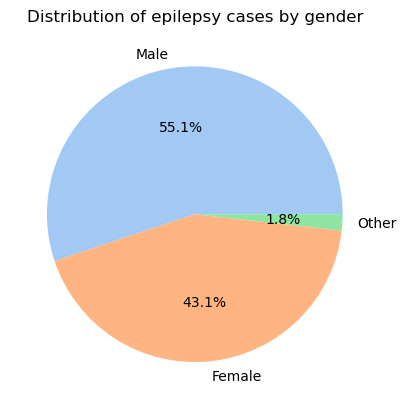

In [13]:
gender_counts = epi["Gender"].value_counts()
sb.set_palette("pastel")
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%")
plt.title("Distribution of epilepsy cases by gender")
plt.show()

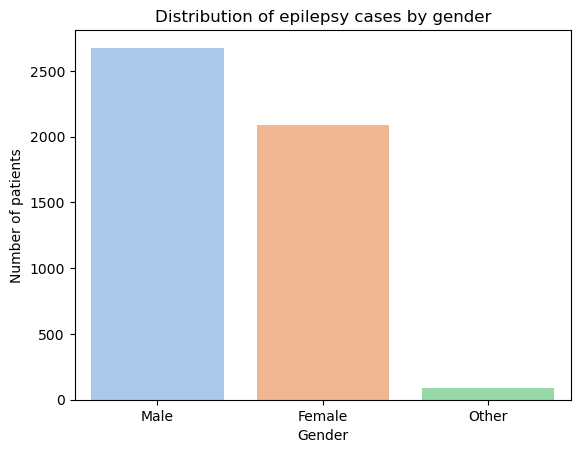

In [14]:
sb.set_palette("pastel")
sb.countplot(data=epi, x="Gender", hue="Gender")
plt.title("Distribution of epilepsy cases by gender")
plt.ylabel("Number of patients")
plt.show()

In [15]:
epi[(epi["Age"] <= 20)]

,Age,Gender,Weight/Kg,Height/Cm,Medication Status,Alcohol or Drug Use,EEG Abnormality Detected,MRI/CT Scan Result,Seizure Frequency/Weekly,Seizure Duration/Seconds,...,Flashing Lights Sensitivity,Loud Sound Sensitivity,Missed Medication,Family History of Epilepsy,Head Injury History,Brain Tumor,History of Stroke,Genetic Disorder,Developmental Delay (in Children),Target/Epilepsy Type
0,15,Male,48.3,168.2,On Medication,Yes,Yes,Normal,1,60,...,Yes,Yes,No,No,No,No,No,No,Yes,Generalized
1,4,Female,56.0,174.5,On Medication,No,Yes,Abnormal,1,30,...,No,No,No,Yes,Yes,Yes,No,No,No,Generalized
5,18,Male,62.1,168.0,On Medication,No,Yes,Abnormal,1,30,...,Yes,No,No,Yes,No,No,No,No,No,Generalized
6,14,Male,53.3,161.8,Not on Medication,No,No,Not Done,2,30,...,No,No,No,Yes,Yes,No,No,Yes,Yes,Absence
8,12,Male,48.9,169.8,Not on Medication,No,No,Normal,1,90,...,No,No,No,Yes,No,No,No,No,No,Complicated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4830,6,Male,45.2,179.7,On Medication,No,Yes,Abnormal,0,60,...,No,No,No,No,No,No,No,No,Yes,Absence
4837,6,Male,61.7,166.3,On Medication,No,No,Normal,2,120,...,No,Yes,Yes,Yes,Yes,No,No,No,No,Generalized
4838,6,Female,75.1,150.3,On Medication,No,Yes,Normal,0,30,...,No,No,Yes,Yes,Yes,No,No,No,No,Not Confirmed
4840,14,Male,97.5,158.1,Not on Medication,No,Yes,Abnormal,1,90,...,Yes,No,No,Yes,No,No,No,No,Yes,Complicated


In [16]:
epi[(epi["Age"] > 20) & (epi["Age"] <= 40)]

,Age,Gender,Weight/Kg,Height/Cm,Medication Status,Alcohol or Drug Use,EEG Abnormality Detected,MRI/CT Scan Result,Seizure Frequency/Weekly,Seizure Duration/Seconds,...,Flashing Lights Sensitivity,Loud Sound Sensitivity,Missed Medication,Family History of Epilepsy,Head Injury History,Brain Tumor,History of Stroke,Genetic Disorder,Developmental Delay (in Children),Target/Epilepsy Type
2,36,Female,44.8,156.2,On Medication,No,Yes,Abnormal,3,30,...,No,Yes,Yes,Yes,No,No,No,No,No,Generalized
3,32,Female,70.4,180.4,Not on Medication,No,Yes,Not Done,0,60,...,Yes,Yes,No,No,No,No,No,No,No,Focal
4,29,Male,54.5,161.7,On Medication,No,Yes,Not Done,1,60,...,No,Yes,No,Yes,No,Yes,No,No,No,Generalized
14,28,Male,93.7,175.7,On Medication,No,Yes,Abnormal,1,90,...,No,No,Yes,Yes,No,No,No,No,No,Generalized
15,30,Male,82.3,160.2,Not on Medication,No,Yes,Normal,0,60,...,No,No,No,No,No,No,No,No,No,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4831,27,Male,96.2,163.9,On Medication,No,Yes,Normal,1,60,...,Yes,No,No,No,No,No,No,No,No,Generalized
4842,36,Female,57.5,156.9,On Medication,No,Yes,Normal,2,30,...,No,No,No,No,No,No,No,No,No,Focal
4843,34,Male,54.0,163.3,On Medication,No,Yes,Abnormal,2,30,...,Yes,No,No,No,No,Yes,No,No,No,Complicated
4847,23,Male,80.6,159.9,Not on Medication,No,Yes,Normal,3,90,...,No,No,No,Yes,Yes,No,No,Yes,No,Generalized


In [17]:
epi[(epi["Age"] > 40) & (epi["Age"] <= 60)]

,Age,Gender,Weight/Kg,Height/Cm,Medication Status,Alcohol or Drug Use,EEG Abnormality Detected,MRI/CT Scan Result,Seizure Frequency/Weekly,Seizure Duration/Seconds,...,Flashing Lights Sensitivity,Loud Sound Sensitivity,Missed Medication,Family History of Epilepsy,Head Injury History,Brain Tumor,History of Stroke,Genetic Disorder,Developmental Delay (in Children),Target/Epilepsy Type
10,55,Male,88.4,166.3,On Medication,No,Yes,Normal,3,30,...,No,No,No,No,Yes,No,No,No,No,Generalized
22,54,Female,80.8,171.5,On Medication,Yes,Yes,Abnormal,1,120,...,Yes,Yes,Yes,Yes,No,No,No,Yes,No,Focal
24,58,Male,56.0,172.6,On Medication,No,Yes,Abnormal,5,30,...,No,Yes,No,Yes,Yes,No,No,No,No,Focal
29,55,Female,68.0,163.6,On Medication,No,Yes,Normal,2,30,...,Yes,Yes,No,No,Yes,No,No,No,No,Generalized
30,44,Male,75.8,153.7,On Medication,Yes,No,Abnormal,1,60,...,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4839,42,Male,57.0,165.3,On Medication,No,Yes,Normal,1,120,...,No,No,No,No,No,No,No,No,No,Focal
4848,49,Male,57.3,160.8,On Medication,No,Yes,Normal,1,60,...,No,No,No,No,Yes,No,No,No,No,Generalized
4849,49,Female,50.8,169.0,On Medication,No,Yes,Normal,0,30,...,No,No,Yes,No,No,No,No,No,No,Generalized
4850,47,Female,58.6,166.5,On Medication,No,Yes,Abnormal,10,90,...,Yes,No,No,Yes,No,No,No,No,No,Generalized


In [18]:
epi[(epi["Age"] > 60)]

,Age,Gender,Weight/Kg,Height/Cm,Medication Status,Alcohol or Drug Use,EEG Abnormality Detected,MRI/CT Scan Result,Seizure Frequency/Weekly,Seizure Duration/Seconds,...,Flashing Lights Sensitivity,Loud Sound Sensitivity,Missed Medication,Family History of Epilepsy,Head Injury History,Brain Tumor,History of Stroke,Genetic Disorder,Developmental Delay (in Children),Target/Epilepsy Type
7,70,Female,93.0,169.7,On Medication,No,Yes,Normal,1,30,...,No,No,No,No,No,No,No,No,No,Absence
9,76,Female,50.6,178.8,On Medication,No,Yes,Abnormal,5,30,...,Yes,No,No,Yes,No,Yes,Yes,No,No,Complicated
16,65,Male,66.0,174.8,Not on Medication,Yes,Yes,Not Done,0,30,...,No,Yes,No,No,No,No,Yes,No,No,Complicated
17,78,Female,36.3,168.6,Not on Medication,No,No,Not Done,0,30,...,Yes,No,No,No,No,No,No,No,No,Normal
19,72,Male,87.3,173.8,On Medication,No,Yes,Abnormal,1,60,...,No,No,No,No,No,No,No,No,No,Generalized
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4844,75,Other,46.4,164.1,On Medication,No,Yes,Normal,10,90,...,No,Yes,No,Yes,No,No,No,No,No,Absence
4845,70,Female,58.9,159.6,Not on Medication,No,Yes,Normal,2,30,...,No,No,No,No,No,No,No,Yes,No,Absence
4846,73,Female,68.9,165.9,On Medication,No,Yes,Not Done,3,30,...,Yes,No,No,Yes,No,No,No,No,No,Focal
4851,76,Female,58.1,170.3,On Medication,No,Yes,Normal,0,60,...,Yes,No,No,Yes,No,No,No,Yes,No,Generalized


In [19]:
Age0_20 = epi[(epi["Age"] <= 20)].shape[0]
Age21_40 = epi[(epi["Age"] > 20) & (epi["Age"] <= 40)].shape[0]
Age41_60 = epi[(epi["Age"] > 40) & (epi["Age"] <= 60)].shape[0]
Age60_plus = epi[(epi["Age"] > 60)].shape[0]
print(Age0_20, Age21_40, Age41_60, Age60_plus)

1215 1183 1241 1217


In [20]:
Age_groups = ["0-20", "21-40", "41-60", "60+"]
Counts = [Age0_20, Age21_40, Age41_60, Age60_plus]

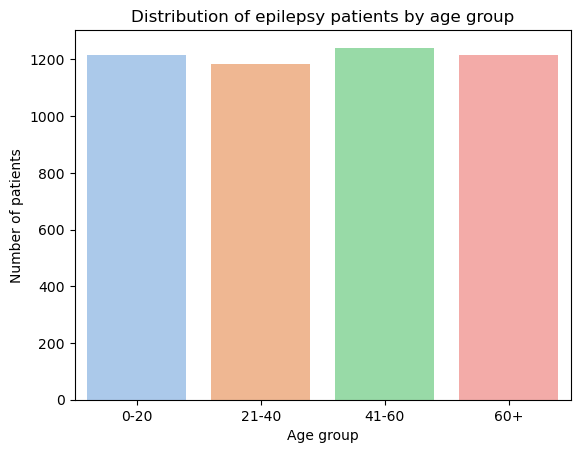

In [66]:
sb.set_palette("pastel")
sb.barplot(x=Age_groups, y=Counts, hue=Age_groups)
plt.title("Distribution of epilepsy patients by age group")
plt.xlabel("Age group")
plt.ylabel("Number of patients")
plt.show()

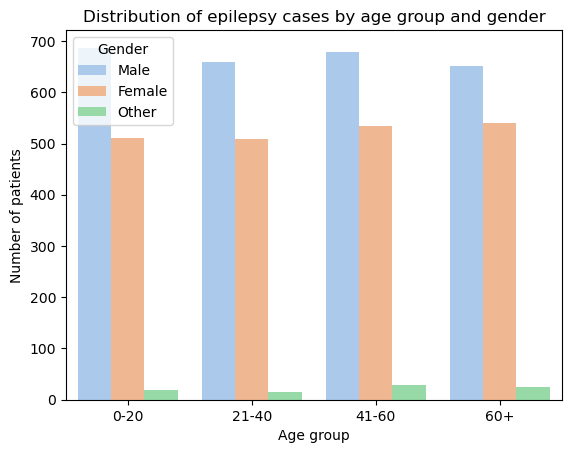

In [69]:
sb.set_palette("pastel")
sb.countplot(data=epi, x="AgeGroup", hue="Gender")
plt.title("Distribution of epilepsy cases by age group and gender")
plt.xlabel("Age group")
plt.ylabel("Number of patients")
plt.show()

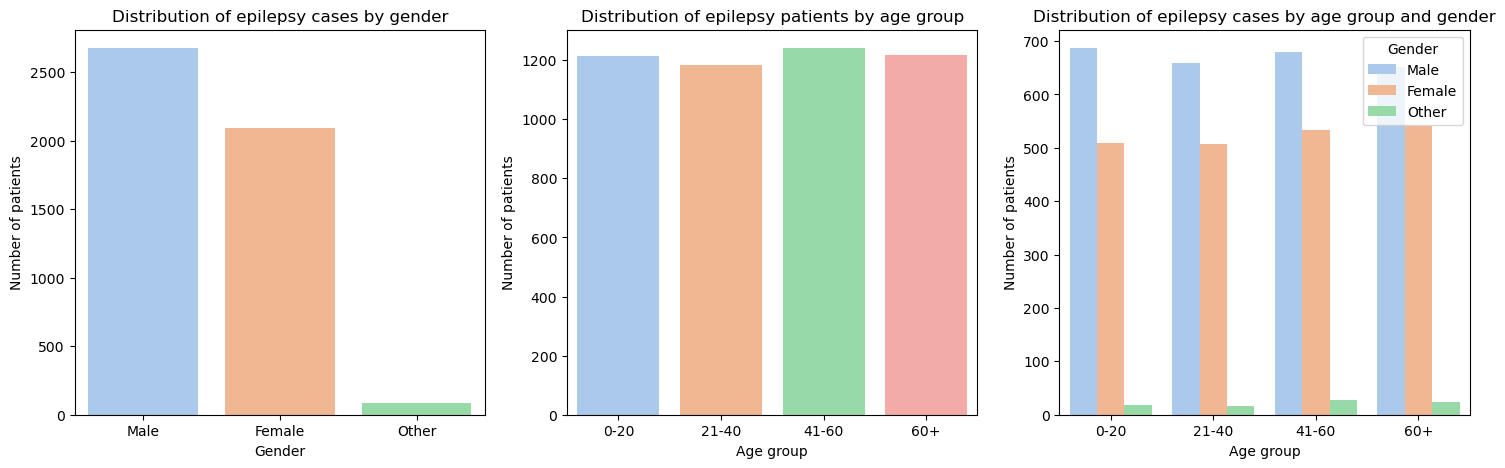

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plt.subplot(1,3,1)
sb.set_palette("pastel")
sb.countplot(data=epi, x="Gender", hue="Gender")
plt.title("Distribution of epilepsy cases by gender")
plt.ylabel("Number of patients")

plt.subplot(1,3,2)
sb.set_palette("pastel")
sb.barplot(x=Age_groups, y=Counts, hue=Age_groups)
plt.title("Distribution of epilepsy patients by age group")
plt.xlabel("Age group")
plt.ylabel("Number of patients")

plt.subplot(1,3,3)
sb.set_palette("pastel")
sb.countplot(data=epi, x="AgeGroup", hue="Gender")
plt.title("Distribution of epilepsy cases by age group and gender")
plt.xlabel("Age group")
plt.ylabel("Number of patients")

plt.show()

After conducting the analysis, it is possible to answer the first research question: How are epilepsy cases distributed across different **age groups and genders?**

**The first visualization illustrates** the distribution of patients by gender. The results indicate that both males and females are well represented in the dataset, with only minor differences in the number of cases between genders. **This suggests that epilepsy in this dataset affects individuals of both genders without a strong gender imbalance.** 
Unfortunately, the author of the dataset does not specify what is meant by the value **"Other"**, so these data cannot be considered statistically significant for the analysis.

**The second chart** presents the distribution of patients across different age groups. The results show that the largest number of cases appears in the middle age groups, indicating that adult patients are more strongly represented in the dataset. **Younger and older age groups appear less frequently.**

**The third visualization** combines both demographic variables — age and gender — allowing a comparison of male and female patients within each age group. **The analysis shows that both genders are present across all age groups, with only moderate variations in their distribution. In some age categories, slight differences between genders can be observed.**

Overall, the analysis suggests that epilepsy cases in this dataset are relatively evenly distributed between genders and span a wide range of ages. This indicates that epilepsy affects individuals across multiple demographic groups rather than being concentrated in a single age or gender category.

2. Is there a relationship between **family history of epilepsy and the occurrence of the disease**?

In [25]:
epi["Family History of Epilepsy"].value_counts()

Family History of Epilepsy
No     3082
Yes    1774
Name: count, dtype: int64

In [26]:
Family_counts = epi["Family History of Epilepsy"].value_counts()

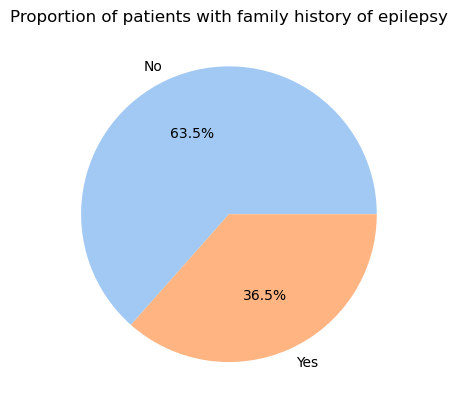

In [27]:
sb.set_palette("pastel")
plt.pie(Family_counts, labels=Family_counts.index, autopct="%1.1f%%")
plt.title("Proportion of patients with family history of epilepsy")
plt.show()

The chart shows the proportion of patients who have a family history of epilepsy compared to those who do not. Such an analysis allows us to assess the prevalence of hereditary factors among epilepsy patients in this dataset.

As we can see, in the majority of cases **(3,082 cases - 63.5%) patients with epilepsy do not have a family history of epileptic disorders.** 
However, there is also a substantial proportion of patients **(1,774 cases - 36.5%) whose families have a history of epilepsy.** 

Therefore, **no clear relationship** can be observed between a family history of epilepsy and the occurrence of epilepsy among patients in this dataset.

3. How do **seizure frequency and duration vary** among patients?

In [28]:
epi[["Seizure Frequency/Weekly", "Seizure Duration/Seconds"]].describe()

,Seizure Frequency/Weekly,Seizure Duration/Seconds
count,4856.000000,4856.000000
mean,1.967875,59.592257
std,2.395971,29.888887
min,0.000000,30.000000
25%,0.000000,30.000000
50%,1.000000,60.000000
75%,3.000000,90.000000
max,10.000000,120.000000


In [29]:
epi["Seizure Frequency/Weekly"].value_counts().sort_index()

Seizure Frequency/Weekly
0     1461
1     1198
2      963
3      489
5      497
10     248
Name: count, dtype: int64

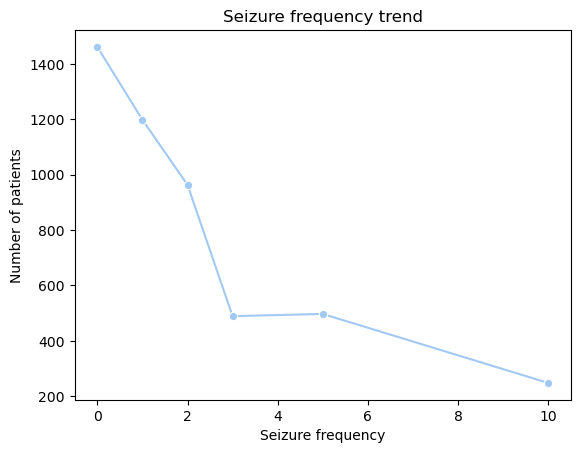

In [72]:
sb.lineplot(x=Freq_counts.index, y=Freq_counts.values, marker="o")
plt.title("Seizure frequency trend")
plt.xlabel("Seizure frequency")
plt.ylabel("Number of patients")
plt.show()

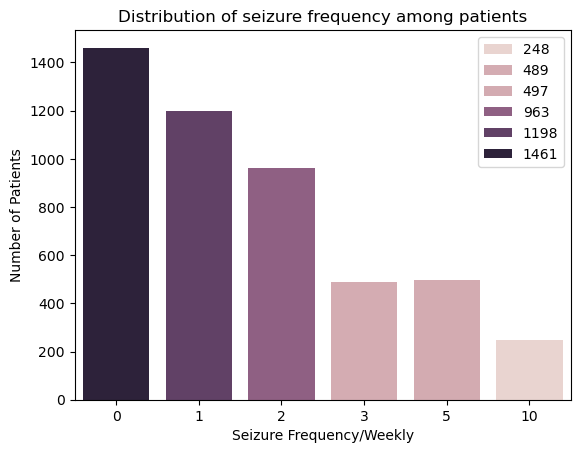

In [30]:
Freq_counts = epi["Seizure Frequency/Weekly"].value_counts().sort_index()
sb.set_palette("pastel")
sb.barplot(x=Freq_counts.index, y=Freq_counts.values, hue=Freq_counts.values)
plt.title("Distribution of seizure frequency among patients")
plt.xlabel("Seizure Frequency/Weekly")
plt.ylabel("Number of Patients")
plt.show()

The distribution of seizure frequency shows that most patients experience **0–1 seizure per week.** This suggests that seizures occur relatively infrequently for a large portion of patients or may be effectively managed.

As seizure frequency increases, the number of patients decreases. The highest seizure frequencies appear much less frequently, indicating that severe cases with very frequent seizures are less common in the dataset.

In [31]:
Low = epi[epi["Seizure Frequency/Weekly"] < 2].shape[0]
Moderate = epi[(epi["Seizure Frequency/Weekly"] >= 2) & (epi["Seizure Frequency/Weekly"] < 5)].shape[0]
High = epi[epi["Seizure Frequency/Weekly"] >= 5].shape[0]
FrequencyGroup = [Low, Moderate, High]
print(FrequencyGroup)

[2659, 1452, 745]


In [32]:
Short = epi[epi["Seizure Duration/Seconds"] < 40].shape[0]
Medium = epi[(epi["Seizure Duration/Seconds"] >= 40) & (epi["Seizure Duration/Seconds"] < 80)].shape[0]
Long = epi[epi["Seizure Duration/Seconds"] >= 80].shape[0]
DurationGroup=[Short,Medium,Long]
print(DurationGroup)

[1966, 1467, 1423]


The analysis shows that most patients in the dataset fall into the **low seizure frequency category (2659)**, indicating that seizures occur relatively infrequently for the majority of patients. A smaller number of patients experience **moderate seizure frequency (1452)**, while the **high frequency category (745)** contains the fewest patients.

In contrast, seizure duration appears to be more evenly distributed across **short, medium, and long seizure categories**. This suggests that seizure frequency and seizure duration may represent different characteristics of epilepsy and can vary independently among patients.

4. Are medical indicators such as **EEG abnormalities or MRI/CT scan results** associated with epilepsy characteristics?

In [33]:
epi["EEG Abnormality Detected"].value_counts()

EEG Abnormality Detected
Yes    4136
No      720
Name: count, dtype: int64

In [34]:
epi["MRI/CT Scan Result"].value_counts()

MRI/CT Scan Result
Normal      2383
Abnormal    1751
Not Done     722
Name: count, dtype: int64

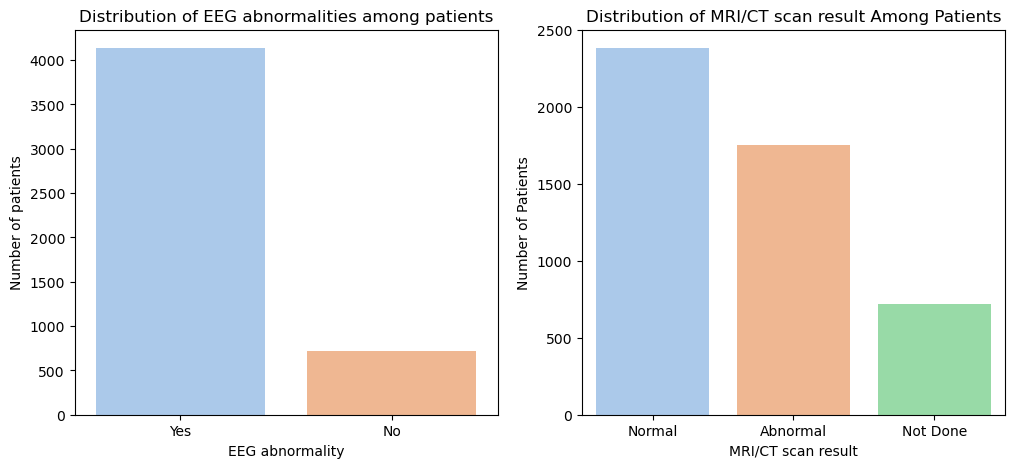

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plt.subplot(1,2,1)
sb.set_palette("pastel")
sb.countplot(data=epi, x="EEG Abnormality Detected", hue="EEG Abnormality Detected")
plt.title("Distribution of EEG abnormalities among patients")
plt.xlabel("EEG abnormality")
plt.ylabel("Number of patients")

plt.subplot(1,2,2)
sb.set_palette("pastel")
sb.countplot(data=epi, x="MRI/CT Scan Result", hue="MRI/CT Scan Result")
plt.title("Distribution of MRI/CT scan result Among Patients")
plt.xlabel("MRI/CT scan result")
plt.ylabel("Number of Patients")
plt.show()

The analysis of medical indicators shows that the majority of patients in the dataset **have detected EEG abnormalities (4,136 cases)**, while a smaller portion of patients have **normal EEG results (720 cases)**. This suggests that **EEG abnormalities frequently accompany epilepsy and may represent an important diagnostic indicator of the condition.**

In contrast, MRI/CT scan results are more evenly distributed: **2,383 patients have normal scan results, 1,751 patients show abnormal findings, and 722 patients did not undergo the examination.** This may indicate that structural brain abnormalities are not present in all epilepsy patients, suggesting that **MRI/CT scans may be less sensitive in detecting epilepsy compared to EEG.**

Overall, the analysis suggests that EEG abnormalities appear more strongly associated with epilepsy in this dataset, while MRI/CT results show a weaker relationship with the condition.

In [36]:
epi.groupby("EEG Abnormality Detected")["Seizure Frequency/Weekly"].mean()

EEG Abnormality Detected
No     1.945833
Yes    1.971712
Name: Seizure Frequency/Weekly, dtype: float64

In [37]:
epi.groupby("EEG Abnormality Detected")["Seizure Duration/Seconds"].mean()

EEG Abnormality Detected
No     59.625000
Yes    59.586557
Name: Seizure Duration/Seconds, dtype: float64

In [38]:
epi.groupby("MRI/CT Scan Result")["Seizure Frequency/Weekly"].mean()

MRI/CT Scan Result
Abnormal    1.945174
Normal      1.969366
Not Done    2.018006
Name: Seizure Frequency/Weekly, dtype: float64

In [39]:
epi.groupby("MRI/CT Scan Result")["Seizure Duration/Seconds"].mean()

MRI/CT Scan Result
Abnormal    59.109081
Normal      60.239194
Not Done    58.628809
Name: Seizure Duration/Seconds, dtype: float64

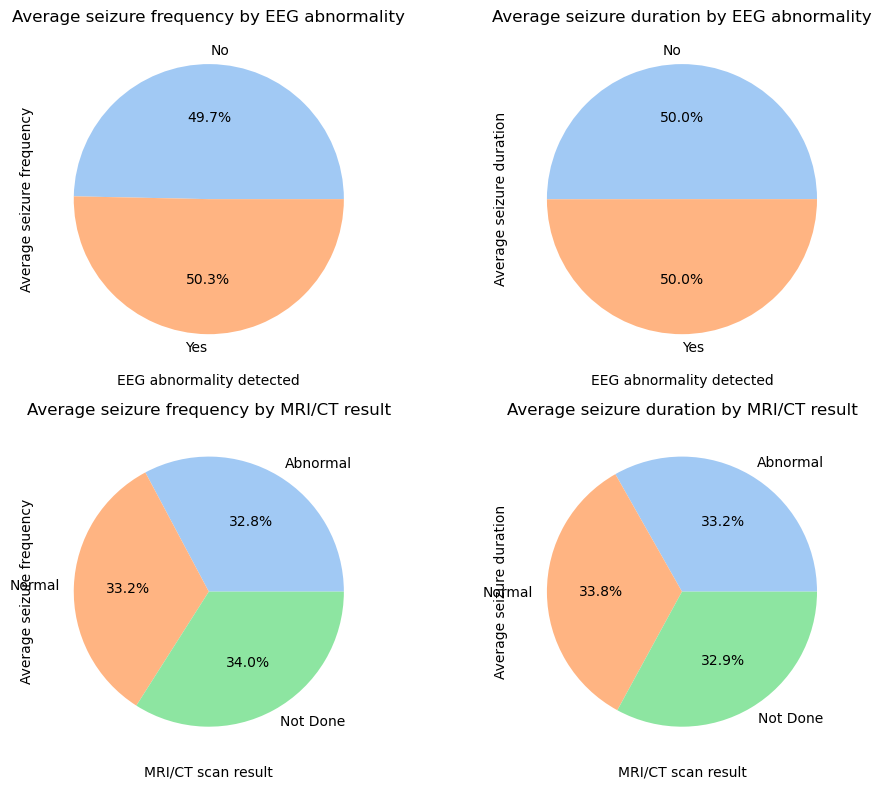

In [62]:
eeg_freg=epi.groupby("EEG Abnormality Detected")["Seizure Frequency/Weekly"].mean()
eeg_dur=epi.groupby("EEG Abnormality Detected")["Seizure Duration/Seconds"].mean()
mri_freg=epi.groupby("MRI/CT Scan Result")["Seizure Frequency/Weekly"].mean()
mri_dur=epi.groupby("MRI/CT Scan Result")["Seizure Duration/Seconds"].mean()

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
sb.set_palette("pastel")
eeg_freg.plot(kind="pie",autopct="%1.1f%%")
plt.title("Average seizure frequency by EEG abnormality")
plt.xlabel("EEG abnormality detected")
plt.ylabel("Average seizure frequency")

plt.subplot(2,2,2)
sb.set_palette("pastel")
eeg_dur.plot(kind="pie",autopct="%1.1f%%")
plt.title("Average seizure duration by EEG abnormality")
plt.xlabel("EEG abnormality detected")
plt.ylabel("Average seizure duration")

plt.subplot(2,2,3)
sb.set_palette("pastel")
mri_freg.plot(kind="pie",autopct="%1.1f%%")
plt.title("Average seizure frequency by MRI/CT result")
plt.xlabel("MRI/CT scan result")
plt.ylabel("Average seizure frequency")

plt.subplot(2,2,4)
sb.set_palette("pastel")
mri_dur.plot(kind="pie",autopct="%1.1f%%")
plt.title("Average seizure duration by MRI/CT result")
plt.xlabel("MRI/CT scan result")
plt.ylabel("Average seizure duration")

plt.tight_layout()
plt.show()

To investigate the potential relationship between medical indicators and epilepsy characteristics, EEG abnormalities and MRI/CT scan results were analyzed in relation to seizure frequency and seizure duration.

The comparison of mean seizure frequency and seizure duration shows **only minimal differences between patients with different EEG and MRI/CT results.** The results do not indicate a strong association between medical indicators and seizure characteristics in this dataset.

### Overall Conclusion

Within the scope of this study, I observed that epilepsy—both in humans and in my own dog—remains insufficiently understood and **difficult to analyze**. Most of the variables in the dataset appear to be relatively evenly distributed, suggesting that epilepsy can occur regardless of gender, genetic predisposition, or findings from MRI or EEG examinations.

This indicates that, based on the available data, epilepsy does not show a strong dependency on any single factor and **may affect individuals across different groups.**

Unfortunately, our understanding of this disease is still limited. It is hoped that in the near future, advances in research will allow for a deeper understanding of neurological disorders such as epilepsy and enable more effective, personalized treatment approaches for patients.

**Thank you for your attention to my project and for considering this important issue.**